# Naive Bayes Classifier for Bank Fraud Detection
This notebook trains a Naive Bayes model on cleaned fraud data and evaluates it using standardized metrics.

## 1. Imports and Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, average_precision_score, 
                             roc_auc_score, precision_recall_curve, f1_score, make_scorer)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

## 2. Evaluation Function

In [15]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        roc_auc = roc_auc_score(y_true, y_proba)
        metrics['roc_auc'] = roc_auc
        print(f"ROC AUC:                   {roc_auc:.4f}")

        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

## 3. Load and Prepare Data

In [4]:
folds = []

for i in range(1, 6):
    val_df = pd.read_csv(f"../../data/preprocessed/fold_{i}_val.csv")
    train_dfs = []

    for j in range(1, 6):
        if j != i:
            train_dfs.append(pd.read_csv(f"../../data/preprocessed/fold_{j}_train.csv"))
    
    train_df = pd.concat(train_dfs, ignore_index=True)
    folds.append((train_df, val_df))

## 4. Train Naive Bayes Model with Hyperparameter Tuning & 5. Evaluate Model


--- Fold 1 ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Parameters: {'var_smoothing': 1e-09}
Best F1 Score from Inner CV: 0.8733982303126787
Classification Report:
              precision    recall  f1-score   support

           0     0.9947    0.8390    0.9102    178712
           1     0.0377    0.5870    0.0708      1920

    accuracy                         0.8363    180632
   macro avg     0.5162    0.7130    0.4905    180632
weighted avg     0.9846    0.8363    0.9013    180632


Confusion Matrix:
[[149934  28778]
 [   793   1127]]

Precision: 0.0377
Recall:    0.5870
F1 Score:  0.0708
AUC-PR (Average Precision): 0.0652
ROC AUC:                   0.7605


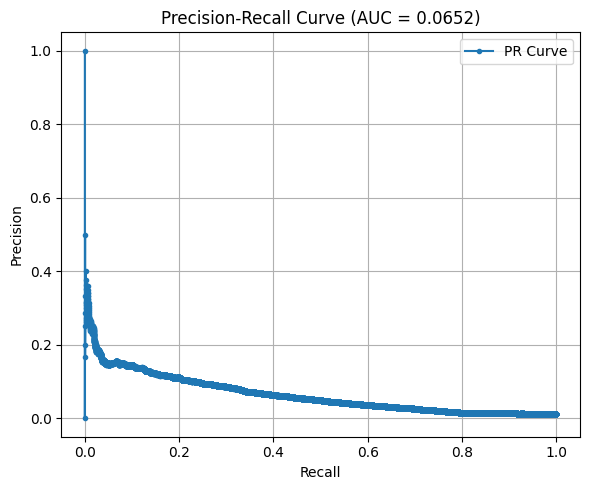


--- Fold 2 ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Parameters: {'var_smoothing': 1e-09}
Best F1 Score from Inner CV: 0.8735449986939589
Classification Report:
              precision    recall  f1-score   support

           0     0.9949    0.8400    0.9109    178711
           1     0.0385    0.5955    0.0723      1921

    accuracy                         0.8374    180632
   macro avg     0.5167    0.7177    0.4916    180632
weighted avg     0.9847    0.8374    0.9020    180632


Confusion Matrix:
[[150113  28598]
 [   777   1144]]

Precision: 0.0385
Recall:    0.5955
F1 Score:  0.0723
AUC-PR (Average Precision): 0.0678
ROC AUC:                   0.7680


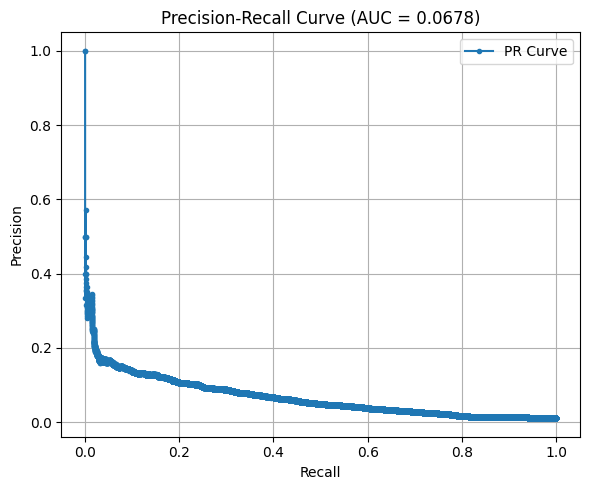


--- Fold 3 ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Parameters: {'var_smoothing': 1e-09}
Best F1 Score from Inner CV: 0.8737377839825274
Classification Report:
              precision    recall  f1-score   support

           0     0.9949    0.8391    0.9104    178711
           1     0.0387    0.6026    0.0727      1920

    accuracy                         0.8366    180631
   macro avg     0.5168    0.7209    0.4916    180631
weighted avg     0.9848    0.8366    0.9015    180631


Confusion Matrix:
[[149963  28748]
 [   763   1157]]

Precision: 0.0387
Recall:    0.6026
F1 Score:  0.0727
AUC-PR (Average Precision): 0.0672
ROC AUC:                   0.7665


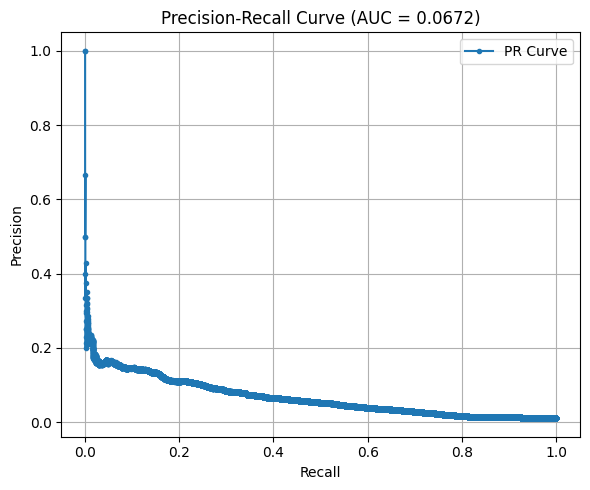


--- Fold 4 ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Parameters: {'var_smoothing': 1e-09}
Best F1 Score from Inner CV: 0.8740366180628442
Classification Report:
              precision    recall  f1-score   support

           0     0.9953    0.8382    0.9100    178711
           1     0.0404    0.6339    0.0759      1920

    accuracy                         0.8360    180631
   macro avg     0.5179    0.7360    0.4930    180631
weighted avg     0.9852    0.8360    0.9012    180631


Confusion Matrix:
[[149793  28918]
 [   703   1217]]

Precision: 0.0404
Recall:    0.6339
F1 Score:  0.0759
AUC-PR (Average Precision): 0.0667
ROC AUC:                   0.7765


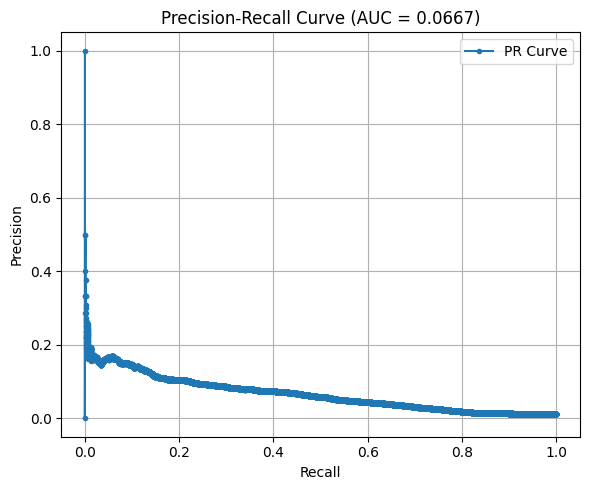


--- Fold 5 ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Parameters: {'var_smoothing': 1e-09}
Best F1 Score from Inner CV: 0.8737667101975559
Classification Report:
              precision    recall  f1-score   support

           0     0.9948    0.8410    0.9115    178711
           1     0.0385    0.5922    0.0723      1920

    accuracy                         0.8384    180631
   macro avg     0.5167    0.7166    0.4919    180631
weighted avg     0.9847    0.8384    0.9026    180631


Confusion Matrix:
[[150304  28407]
 [   783   1137]]

Precision: 0.0385
Recall:    0.5922
F1 Score:  0.0723
AUC-PR (Average Precision): 0.0641
ROC AUC:                   0.7661


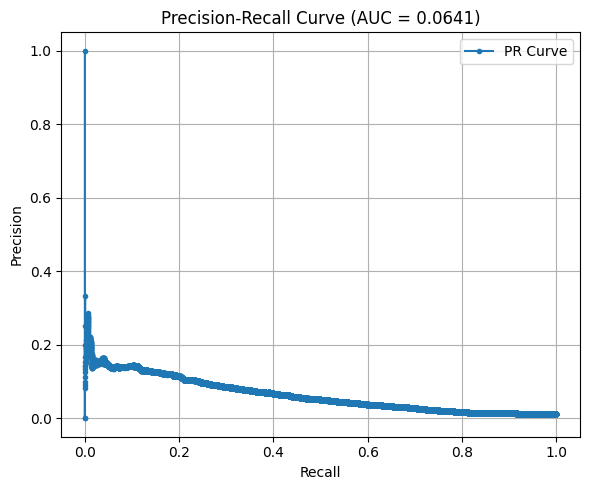

In [ ]:
param_grid = {
    'var_smoothing': np.logspace(-12, -6, 7)
}

for fold_idx, (train_df, val_df) in enumerate(folds):
    print(f"\n--- Fold {fold_idx + 1} ---")

    # Split features and labels
    X_train = train_df.drop(columns='fraud_bool')
    y_train = train_df['fraud_bool']

    X_val = val_df.drop(columns='fraud_bool')
    y_val = val_df['fraud_bool']

    # Parameter tuning with GridSearch / Initialize and perform GridSearch
    gnb = GaussianNB()
    grid_search_nb = GridSearchCV(estimator=gnb,
                                   param_grid=param_grid,
                                   scoring='f1',
                                   cv=5,
                                   verbose=1,
                                   n_jobs=1)

    grid_search_nb.fit(X_train, y_train)

    print("Best Parameters:", grid_search_nb.best_params_)
    print("Best F1 Score from Inner CV:", grid_search_nb.best_score_)

    # Predict and evaluate on the validation set
    best_model = grid_search_nb.best_estimator_
    y_pred = best_model.predict(X_val)
    y_proba = best_model.predict_proba(X_val)[:, 1]

    evaluate_model(y_val, y_pred, y_proba)